In [7]:
import os
os.chdir('./../')

In [10]:
import torch
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader
from torchvision import transforms
import tqdm

import math
from typing import Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils import spectral_norm


import numpy as np
import random

from notebooks.sngp_gpt import SNGPResNet
from src.data.utils import HFDataset
from datasets import load_dataset
from torch.utils.data import ConcatDataset, DataLoader, Dataset
from src.visualization.dempster_shafer_uncertainity_plot import DempsterShaferUncertaintyPlot

In [13]:
seed = 3427
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [14]:
normalize_mean = [0.485, 0.456, 0.406]
normalize_std = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.RandomHorizontalFlip(), # Randomly flip the image horizontally
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

transform_test = transforms.Compose([
    transforms.RandomResizedCrop(224), # Randomly crop and resize to 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=normalize_mean, std=normalize_std)
])

In [9]:

#train model

model = SNGPResNet(
    num_classes=8,         # <-- change to your dataset
    arch="resnet18",
    pretrained=False,         # ok to start from ImageNet
    rff_dim=1024,            # 256–1024 is a good range
    length_scale=1.0,
    ridge_penalty=1e-3,
    cov_momentum=0.999,
    mean_field=True,
).cuda()


# 2) optimizer
optim = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

data = load_dataset("nirschl-lab/acevedo_et_al_2020")
data_train_ = data['train'] #load_dataset(self.data_dir, split="train",)
data_train = HFDataset(data_train_, transform=transform_train, fold='train')
data_val_ = data["validation"] #load_dataset(self.data_dir, split="validation",)
data_val = HFDataset(data_val_, transform=transform_train, fold='val')

# 3) dataloaders (replace with your dataset)
train_loader = DataLoader(data_train, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(data_val,   batch_size=2048, shuffle=False, num_workers=4, pin_memory=True)

prev_val_acc = 0.0

# 4) train
for epoch in tqdm.tqdm(range(1, 101)):
    model.train()
    losses = []
    for image_ids, images, targets, fold in train_loader:
        images, targets = images.cuda(non_blocking=True), targets.cuda(non_blocking=True)
        mf_logits, raw_logits, pred_var = model(images, update_cov=True)
        loss = F.cross_entropy(mf_logits, targets)
        losses.append(loss.item())
        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
    print(f"Epoch {epoch}: train loss = {sum(losses)/len(losses):.4f}")

    # quick eval
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for image_ids, images, targets, fold in val_loader:
            images, targets = images.cuda(), targets.cuda()
            mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
            pred = mf_logits.argmax(dim=1)
            correct += (pred == targets).sum().item()
            total += targets.numel()
    val_acc = correct/total
    print(f"Epoch {epoch}: val acc = {val_acc:.4f}")
    if val_acc > prev_val_acc:
        print(f'improved accuracy - {val_acc:.4f} over {prev_val_acc:.4f}, saving model...')
        torch.save(model.state_dict(), f"notebooks/sngp_seed_{seed}_resnet18_v2_checkpoint.pth")
        prev_val_acc = val_acc
torch.save(model.state_dict(), f"notebooks/sngp_seed_{seed}_resnet18_v2_lastcheckpoint.pth")


  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1: train loss = 2.0789


  0%|          | 0/100 [00:25<?, ?it/s]

Epoch 1: val acc = 0.2750
improved accuracy - 0.2750 over 0.0000, saving model...


NameError: name 'seed' is not defined

## resnet18 model

In [15]:
# 1) build model
model = SNGPResNet(
    num_classes=8,         # <-- change to your dataset
    arch="resnet18",
    pretrained=False,         # ok to start from ImageNet
    rff_dim=1024,            # 256–1024 is a good range
    length_scale=1.0,
    ridge_penalty=1e-3,
    cov_momentum=0.999,
    mean_field=True,
).cuda()

model.load_state_dict(torch.load(f"notebooks/sngp_seed_{seed}_resnet18_v2_checkpoint.pth"))

model.eval()

SNGPResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=T

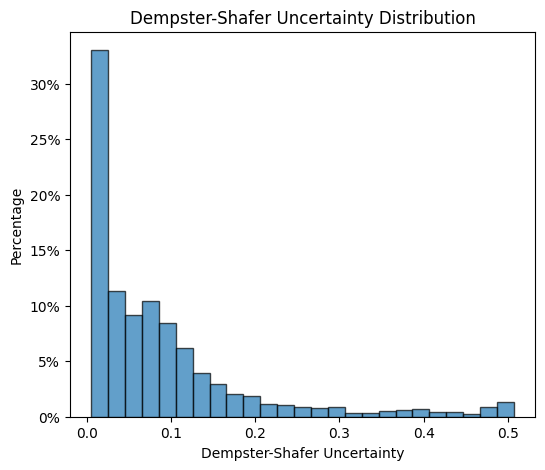

In [15]:
data = load_dataset("nirschl-lab/acevedo_et_al_2020")
ood_data_ = data['test'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='test')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
# quick eval
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


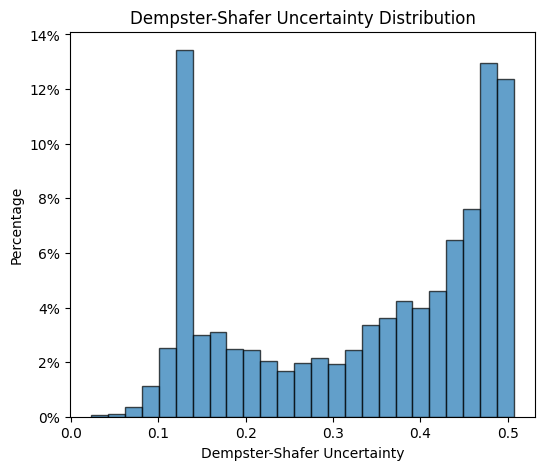

In [16]:
data = load_dataset("nirschl-lab/kather_et_al_2016")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


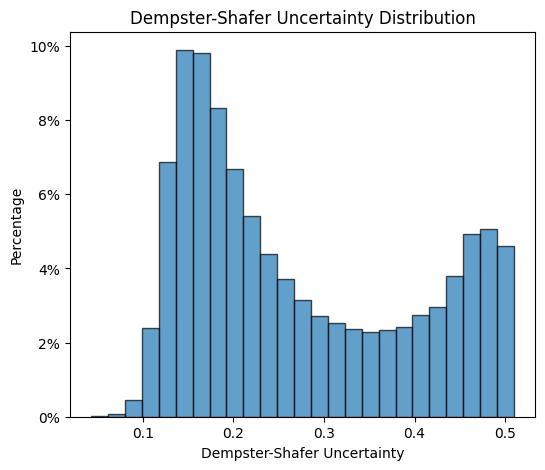

: 

In [ ]:
data = load_dataset("nirschl-lab/kather_et_al_2018")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


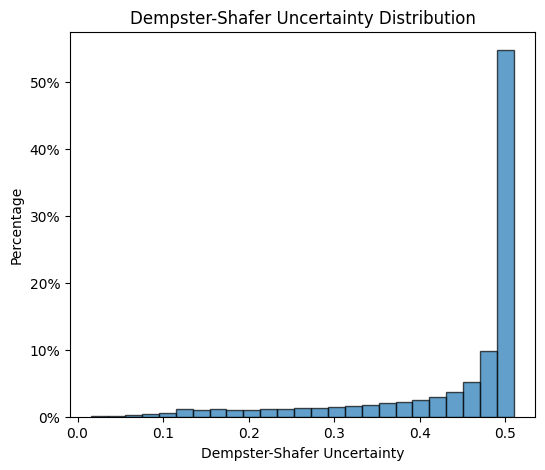

In [18]:
data = load_dataset("nirschl-lab/tang_et_al_2019")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


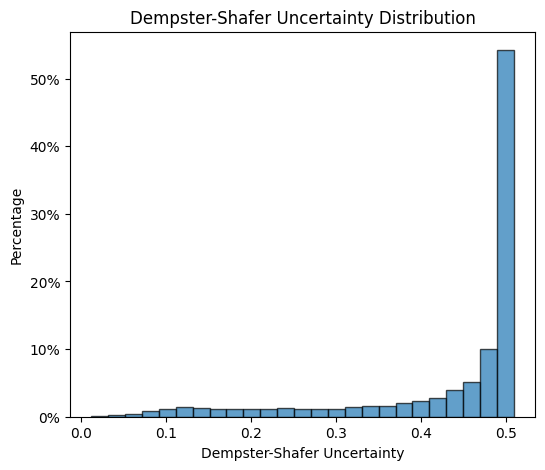

In [19]:
data = load_dataset("nirschl-lab/wong_et_al_2022")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


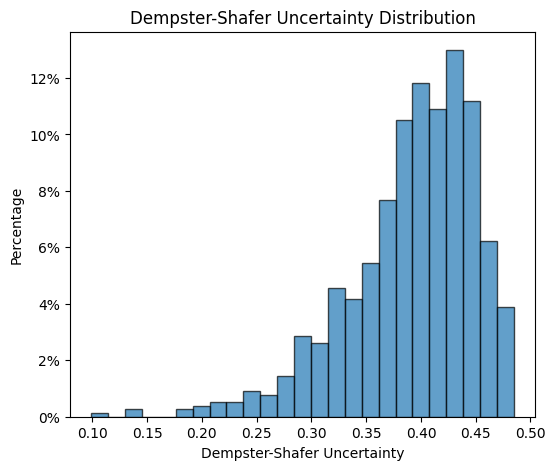

In [16]:
data = load_dataset("nirschl-lab/nirschl_et_al_2018")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


In [ ]:
data = load_dataset("nirschl-lab/jung_et_al_2022")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_test, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


NameError: name 'load_dataset' is not defined

## resnet50

In [11]:
# 1) build model
model = SNGPResNet(
    num_classes=8,         # <-- change to your dataset
    arch="resnet50",
    pretrained=False,         # ok to start from ImageNet
    rff_dim=1024,            # 256–1024 is a good range
    length_scale=1.0,
    ridge_penalty=1e-3,
    cov_momentum=0.999,
    mean_field=True,
).cuda()

model.load_state_dict(torch.load("notebooks/sngp_resnet50_checkpoint.pth"))

model.eval()

SNGPResNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(

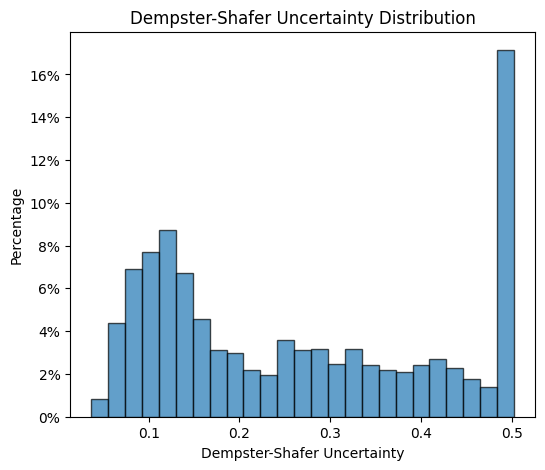

In [12]:
data = load_dataset("nirschl-lab/acevedo_et_al_2020")
ood_data_ = data['test'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_train, fold='test')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=False, num_workers=4, pin_memory=True)
# quick eval
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


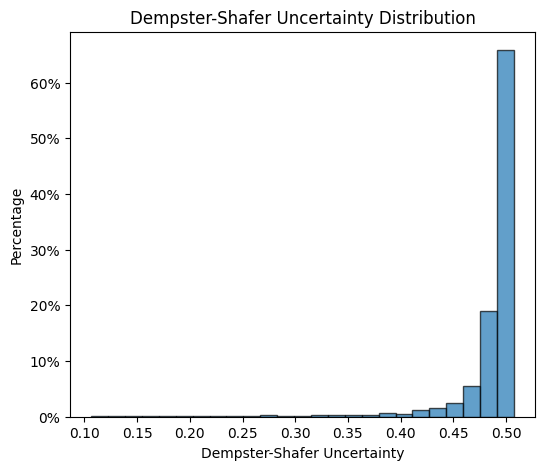

In [13]:
data = load_dataset("nirschl-lab/kather_et_al_2016")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_train, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


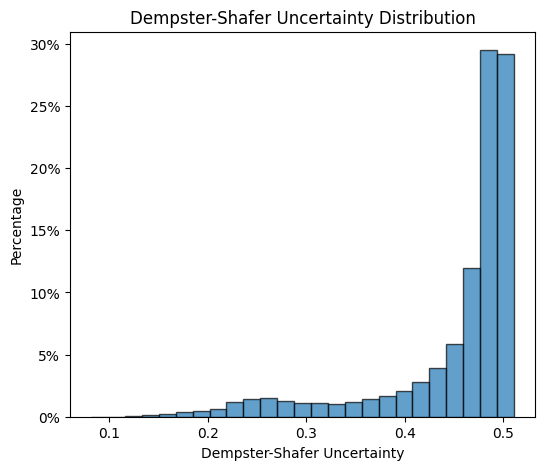

In [14]:
data = load_dataset("nirschl-lab/kather_et_al_2018")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_train, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())


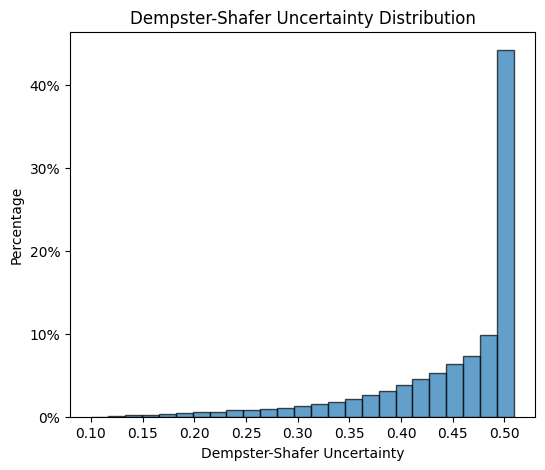

In [15]:
data = load_dataset("nirschl-lab/tang_et_al_2019")
ood_data_ = data['train'] #load_dataset(self.data_dir, split="train",)
ood_data = HFDataset(ood_data_, transform=transform_train, fold='train')
ood_loader = DataLoader(ood_data, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)
# quick eval
model.eval()
all_logits = []
correct = total = 0
with torch.no_grad():
    for image_ids, images, targets, fold in ood_loader:
        images, targets = images.cuda(), targets.cuda()
        mf_logits, _, _ = model(images, update_cov=False)  # freeze cov during eval
        all_logits.append(mf_logits)
        pred = mf_logits.argmax(dim=1)
        correct += (pred == targets).sum().item()
        total += targets.numel()
# print(f"Epoch {epoch}: val acc = {correct/total:.4f}")
all_logits = torch.cat(all_logits, dim=0)
fig = DempsterShaferUncertaintyPlot(all_logits.cpu())
